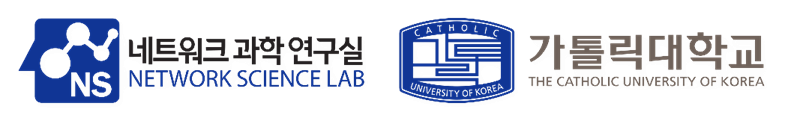

# 📊 Week 2: Message Passing in Graph Neural Networks

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Neural-Networks-Fall-2026/blob/main/W2/Sample_Code_2.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

### Overview

In this notebook, we will explore **Message Passing**, the fundamental mechanism behind most Graph Neural Networks (GNNs). We will use **Zachary's Karate Club** - a classic social network dataset - to:

1. **Understand the dataset**: Load and visualize the Karate Club graph.
2. **Learn the theory**: Understand the message passing framework and its mathematical formulation.
3. **Build from scratch**: Implement a custom message passing GNN layer step-by-step.
4. **Visualize information flow**: Graphically show how messages propagate through the network.
5. **Track representation changes**: Observe how node embeddings evolve over multiple message passing rounds.
6. **Compare with PyG**: Use PyTorch Geometric's built-in `GCNConv` layer.
7. **Apply to a task**: Perform node classification on the Karate Club.

---

## 1. Setup and Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib import cm
from torch_geometric.datasets import KarateClub
from torch_geometric.nn import GCNConv, MessagePassing
from torch_geometric.utils import to_networkx, add_self_loops, degree

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

print('Setup complete!')
print(f'PyTorch version: {torch.__version__}')
print(f'NumPy version: {np.__version__}')

---

## 2. Loading and Exploring Zachary's Karate Club

### Background

**Zachary's Karate Club** (1977) is one of the most famous datasets in network science. It represents the social relationships between 34 members of a university karate club. During the study, a conflict arose between the club's administrator (node 0) and the instructor (node 33), eventually causing the club to split into two separate groups.

This makes it an ideal dataset for understanding GNNs because:
- It has a **clear community structure** (two groups).
- The graph is **small enough to visualize** completely.
- **Node classification** (predicting which group each member joins) is a natural task.

In [ ]:
# Load the Karate Club graph from PyTorch Geometric
dataset = KarateClub()
data = dataset[0]

# Use the original two-way split: instructor (Officer) vs. administrator (Mr. Hi)
club_graph = nx.karate_club_graph()
data.y = torch.tensor(
    [0 if club_graph.nodes[node]['club'] == 'Mr. Hi' else 1
     for node in range(data.num_nodes)],
    dtype=torch.long,
 )
num_classes = 2

# PyG provides one training mask per original class; use one labeled node per binary class
data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.train_mask[0] = True   # Mr. Hi
data.train_mask[33] = True  # Officer

print('='*60)
print("Zachary's Karate Club - Dataset Summary")
print('='*60)
print(f'Number of nodes (members):    {data.num_nodes}')
print(f'Number of edges (connections):{data.num_edges}')
print(f'Number of node features:      {data.num_node_features}')
print(f'Number of classes (groups):   {num_classes}')
print(f'Has isolated nodes:           {data.has_isolated_nodes()}')
print(f'Has self-loops:               {data.has_self_loops()}')
print(f'Is undirected:                {data.is_undirected()}')
print('='*60)
print(f'\nNode feature matrix shape:  {data.x.shape}')
print(f'Edge index shape:           {data.edge_index.shape}')
print(f'Labels (y):                 {data.y}')
print(f'Train mask:                 {data.train_mask}')

Zachary's Karate Club — Dataset Summary
Number of nodes (members):    34
Number of edges (connections):156
Number of node features:      34
Number of classes (groups):   2
Has isolated nodes:           False
Has self-loops:               False
Is undirected:                True

Node feature matrix shape:  torch.Size([34, 34])
Edge index shape:           torch.Size([2, 156])
Labels (y):                 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
Train mask:                 tensor([ True, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False,  True])


### 2.1 Visualizing the Karate Club Graph

Let's visualize the graph with nodes colored by their ground-truth community membership.

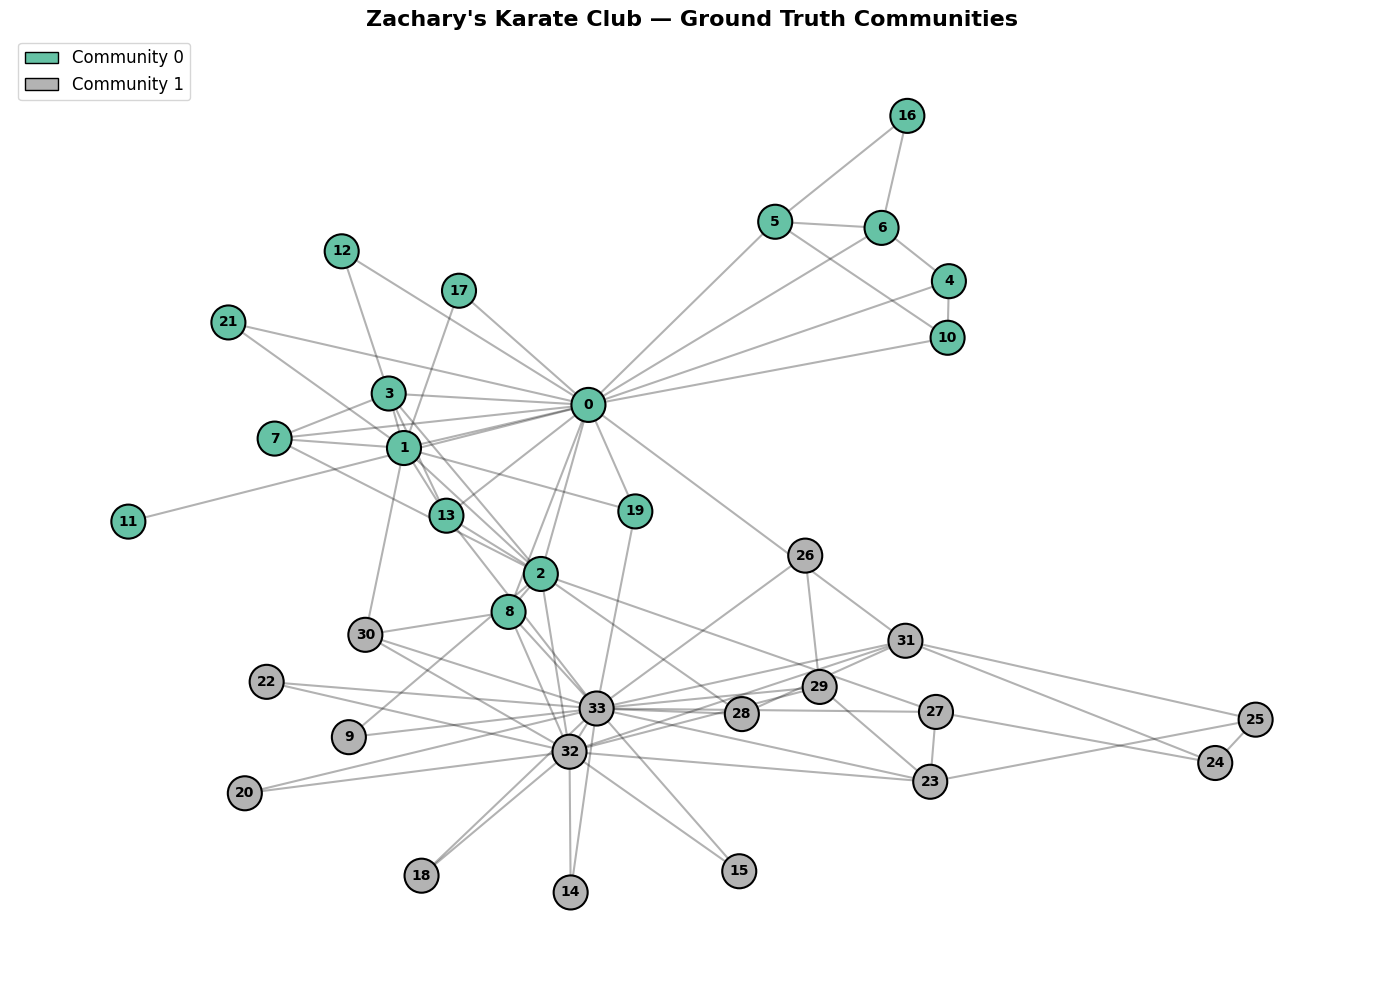

In [ ]:
# Convert to NetworkX for visualization
G = to_networkx(data, to_undirected=True)
pos = nx.spring_layout(G, seed=42, k=0.5)  # Fixed layout for consistency

# Color map based on ground-truth labels
labels = data.y.numpy()
num_classes = len(np.unique(labels))
cmap = cm.get_cmap('Set2', num_classes)
node_colors = [cmap(labels[i]) for i in range(data.num_nodes)]

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.3, width=1.5, ax=ax)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600,
                       edgecolors='black', linewidths=1.5, ax=ax)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)

# Legend
legend_elements = [mpatches.Patch(facecolor=cmap(i), edgecolor='black',
                                  label=f'Community {i}')
                   for i in range(num_classes)]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12)

ax.set_title("Zachary's Karate Club - Ground Truth Communities",
             fontsize=16, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### 2.2 Examining the Adjacency Structure

Let's also look at the **adjacency matrix** and **degree distribution** of the graph.

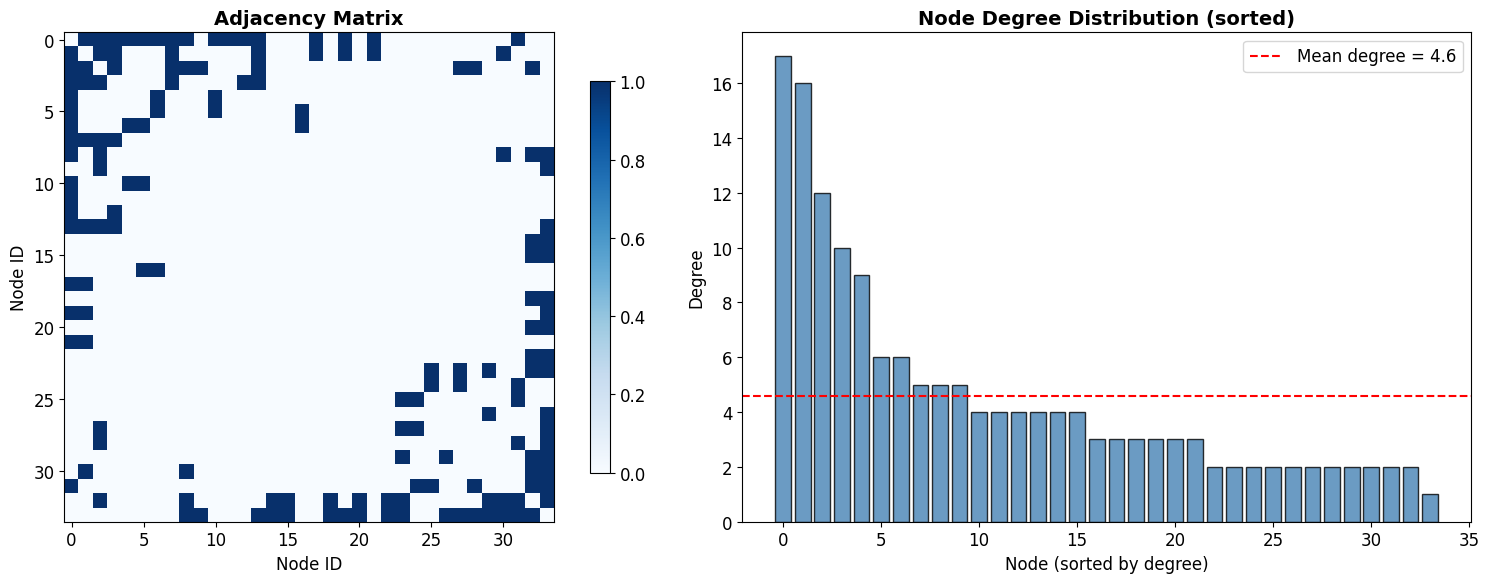


Degree statistics:
  Min degree:  1
  Max degree:  17 (Node 33)
  Mean degree: 4.59


In [4]:
# Build adjacency matrix from edge_index
adj_matrix = nx.adjacency_matrix(G).todense()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot adjacency matrix
im = axes[0].imshow(adj_matrix, cmap='Blues', interpolation='none')
axes[0].set_title('Adjacency Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Node ID')
axes[0].set_ylabel('Node ID')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Plot degree distribution
degrees = [G.degree(n) for n in G.nodes()]
axes[1].bar(range(len(degrees)), sorted(degrees, reverse=True),
            color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title('Node Degree Distribution (sorted)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Node (sorted by degree)')
axes[1].set_ylabel('Degree')
axes[1].axhline(y=np.mean(degrees), color='red', linestyle='--',
                label=f'Mean degree = {np.mean(degrees):.1f}')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

print(f'\nDegree statistics:')
print(f'  Min degree:  {min(degrees)}')
print(f'  Max degree:  {max(degrees)} (Node {np.argmax(degrees)})')
print(f'  Mean degree: {np.mean(degrees):.2f}')

---

## 3. The Message Passing Framework - Theory

### 3.1 Core Idea

The **message passing paradigm** is the foundation of most GNNs. The key insight is:

> **A node's representation should be informed by its neighbors.**

At each layer (or "round") of message passing, every node:
1. **Collects messages** from its neighbors.
2. **Aggregates** those messages (e.g., sum, mean, max).
3. **Updates** its own representation based on the aggregated information.

### 3.2 Mathematical Formulation

For a node $v$ at layer $k$, the general message passing update can be written as:

$$
\mathbf{h}_v^{(k)} = \text{UPDATE}^{(k)} \left( \mathbf{h}_v^{(k-1)}, \text{AGGREGATE}^{(k)} \left( \left\{ \mathbf{m}_{u \to v}^{(k)} : u \in \mathcal{N}(v) \right\} \right) \right)
$$

where:
- $\mathbf{h}_v^{(k)}$ is the feature/embedding of node $v$ at layer $k$
- $\mathcal{N}(v)$ is the set of neighbors of node $v$
- $\mathbf{m}_{u \to v}^{(k)}$ is the **message** sent from node $u$ to node $v$ at layer $k$
- **AGGREGATE** combines all incoming messages (e.g., sum, mean)
- **UPDATE** produces the new node embedding

### 3.3 GCN-style Message Passing (Kipf & Welling, 2017)

In the **Graph Convolutional Network (GCN)**, the message passing simplifies to:

$$
\mathbf{h}_v^{(k)} = \sigma \left( \mathbf{W}^{(k)} \sum_{u \in \mathcal{N}(v) \cup \{v\}} \frac{1}{\sqrt{\deg(v)} \cdot \sqrt{\deg(u)}} \mathbf{h}_u^{(k-1)} \right)
$$

where:
- $\mathbf{W}^{(k)}$ is a learnable weight matrix at layer $k$
- $\sigma$ is a non-linear activation function (e.g., ReLU)
- $\frac{1}{\sqrt{\deg(v)} \cdot \sqrt{\deg(u)}}$ is the **symmetric normalization** coefficient
- Self-loops ($v \in \mathcal{N}(v)$) are added so each node also considers its own features

### 3.4 The Three Steps in Detail

| Step | Operation | Purpose |
|------|-----------|--------|
| **1. Message** | $\mathbf{m}_{u \to v} = \frac{1}{\sqrt{\deg(u)} \cdot \sqrt{\deg(v)}} \cdot \mathbf{h}_u^{(k-1)}$ | Each neighbor prepares a message (its own features, normalized) |
| **2. Aggregate** | $\mathbf{a}_v = \sum_{u \in \mathcal{N}(v) \cup \{v\}} \mathbf{m}_{u \to v}$ | Sum all incoming messages |
| **3. Update** | $\mathbf{h}_v^{(k)} = \sigma(\mathbf{W}^{(k)} \cdot \mathbf{a}_v)$ | Apply linear transformation + activation |

---

## 4. Implementing Message Passing from Scratch

Before using any library functions, let's implement a **single round of message passing** manually to see exactly how information flows.

### 4.1 Step-by-Step Manual Message Passing

We'll pick a specific node and trace every step of the message passing process.

In [5]:
# Initialize node features (use identity features for clarity)
# Each node gets a one-hot vector so we can track exactly how information mixes
num_nodes = data.num_nodes
X = torch.eye(num_nodes)  # Shape: [34, 34]

print(f'Initial feature matrix shape: {X.shape}')
print(f'\nNode 0 initial features (first 10 dims): {X[0, :10].tolist()}')
print(f'Node 1 initial features (first 10 dims): {X[1, :10].tolist()}')
print(f'\nNote: Each node starts with a unique one-hot vector.')
print(f'      This lets us trace exactly which nodes\' information mixes together.')

Initial feature matrix shape: torch.Size([34, 34])

Node 0 initial features (first 10 dims): [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Node 1 initial features (first 10 dims): [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Note: Each node starts with a unique one-hot vector.
      This lets us trace exactly which nodes' information mixes together.


In [6]:
# Build the normalized adjacency matrix (GCN-style)
# Step 1: Add self-loops
edge_index_with_loops, _ = add_self_loops(data.edge_index, num_nodes=num_nodes)

# Step 2: Compute degree
deg = degree(edge_index_with_loops[0], num_nodes=num_nodes)
deg_inv_sqrt = deg.pow(-0.5)
deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0

# Step 3: Build normalized adjacency matrix A_hat = D^{-1/2} * A * D^{-1/2}
# Using the edge_index (with self-loops)
row, col = edge_index_with_loops
norm_coeffs = deg_inv_sqrt[row] * deg_inv_sqrt[col]

# Create a dense normalized adjacency matrix for visualization
A_hat = torch.zeros(num_nodes, num_nodes)
for i in range(edge_index_with_loops.shape[1]):
    src, dst = row[i].item(), col[i].item()
    A_hat[dst, src] = norm_coeffs[i].item()

print('Normalized Adjacency Matrix (A_hat) statistics:')
print(f'  Shape: {A_hat.shape}')
print(f'  Non-zero entries: {(A_hat != 0).sum().item()}')
print(f'  Row sums (first 5): {A_hat.sum(dim=1)[:5].tolist()}')

Normalized Adjacency Matrix (A_hat) statistics:
  Shape: torch.Size([34, 34])
  Non-zero entries: 190
  Row sums (first 5): [1.8707982301712036, 1.3267700672149658, 1.2976635694503784, 1.009562611579895, 0.8448746204376221]


### 4.2 Tracing Messages for a Specific Node

Let's pick **Node 0** (the club administrator, a hub node) and trace all the messages it receives during one round of message passing.

In [7]:
target_node = 0

# Find neighbors of the target node (including self-loop)
neighbors = []
for i in range(edge_index_with_loops.shape[1]):
    if edge_index_with_loops[1, i].item() == target_node:
        src = edge_index_with_loops[0, i].item()
        neighbors.append(src)

print(f'Node {target_node} receives messages from {len(neighbors)} sources:')
print(f'  Neighbors (including self-loop): {sorted(neighbors)}')
print(f'  Degree (with self-loop): {int(deg[target_node].item())}')
print()

# Show the message from each neighbor
print(f'Messages arriving at Node {target_node}:')
print('-' * 65)
print(f'{"Source":>8} | {"Norm Coeff":>12} | {"Message (non-zero idx, value)"}')
print('-' * 65)

aggregated = torch.zeros(num_nodes)
for src in sorted(neighbors):
    coeff = A_hat[target_node, src].item()
    message = coeff * X[src]
    aggregated += message
    # Only show the non-zero component for readability
    nonzero_idx = src  # since X is identity, only X[src, src] = 1
    print(f'{src:>8} | {coeff:>12.4f} | dim {nonzero_idx}: {message[nonzero_idx].item():.4f}')

print('-' * 65)
print(f'\nAggregated features for Node {target_node} (non-zero entries):')
nonzero_mask = aggregated != 0
nonzero_indices = torch.where(nonzero_mask)[0].tolist()
nonzero_values = aggregated[nonzero_mask].tolist()
for idx, val in zip(nonzero_indices, nonzero_values):
    print(f'  dim {idx}: {val:.4f} (from Node {idx})')

Node 0 receives messages from 17 sources:
  Neighbors (including self-loop): [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
  Degree (with self-loop): 17

Messages arriving at Node 0:
-----------------------------------------------------------------
  Source |   Norm Coeff | Message (non-zero idx, value)
-----------------------------------------------------------------
       0 |       0.0588 | dim 0: 0.0588
       1 |       0.0767 | dim 1: 0.0767
       2 |       0.0731 | dim 2: 0.0731
       3 |       0.0917 | dim 3: 0.0917
       4 |       0.1213 | dim 4: 0.1213
       5 |       0.1085 | dim 5: 0.1085
       6 |       0.1085 | dim 6: 0.1085
       7 |       0.1085 | dim 7: 0.1085
       8 |       0.0990 | dim 8: 0.0990
      10 |       0.1213 | dim 10: 0.1213
      11 |       0.1715 | dim 11: 0.1715
      12 |       0.1400 | dim 12: 0.1400
      13 |       0.0990 | dim 13: 0.0990
      17 |       0.1400 | dim 17: 0.1400
      19 |       0.1213 | dim 19: 0.1213
      21 

---

## 5. Visualizing Information Flow

Now let's graphically demonstrate how messages flow through the network. We'll visualize:
1. Which nodes send messages to a target node.
2. How the **receptive field** grows with each layer.

### 5.1 Message Flow to a Single Node

Let's visualize all messages flowing to **Node 0**.

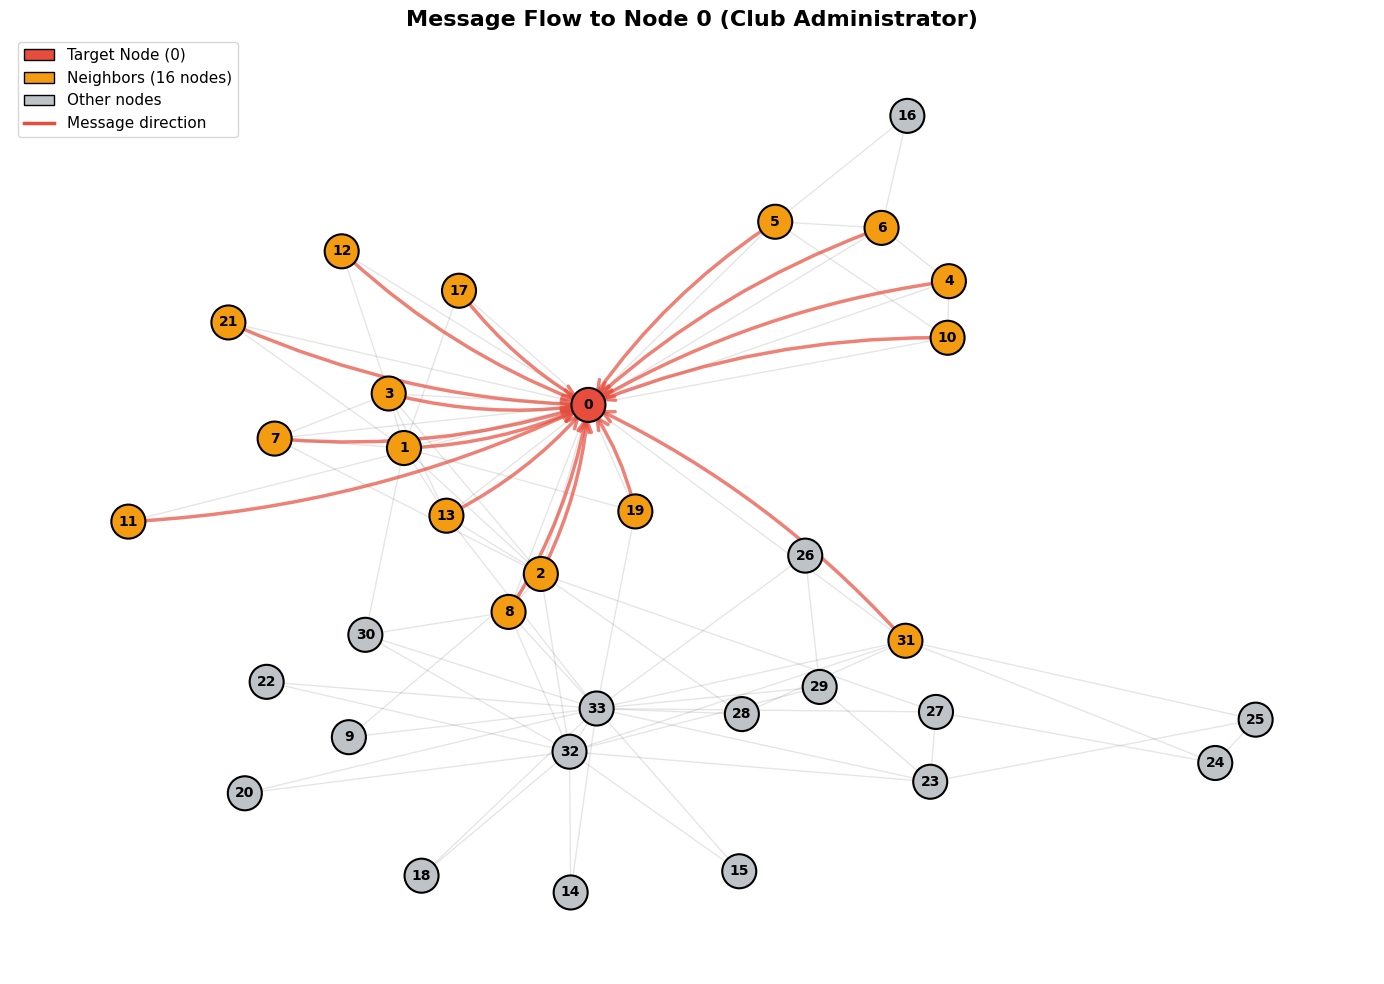

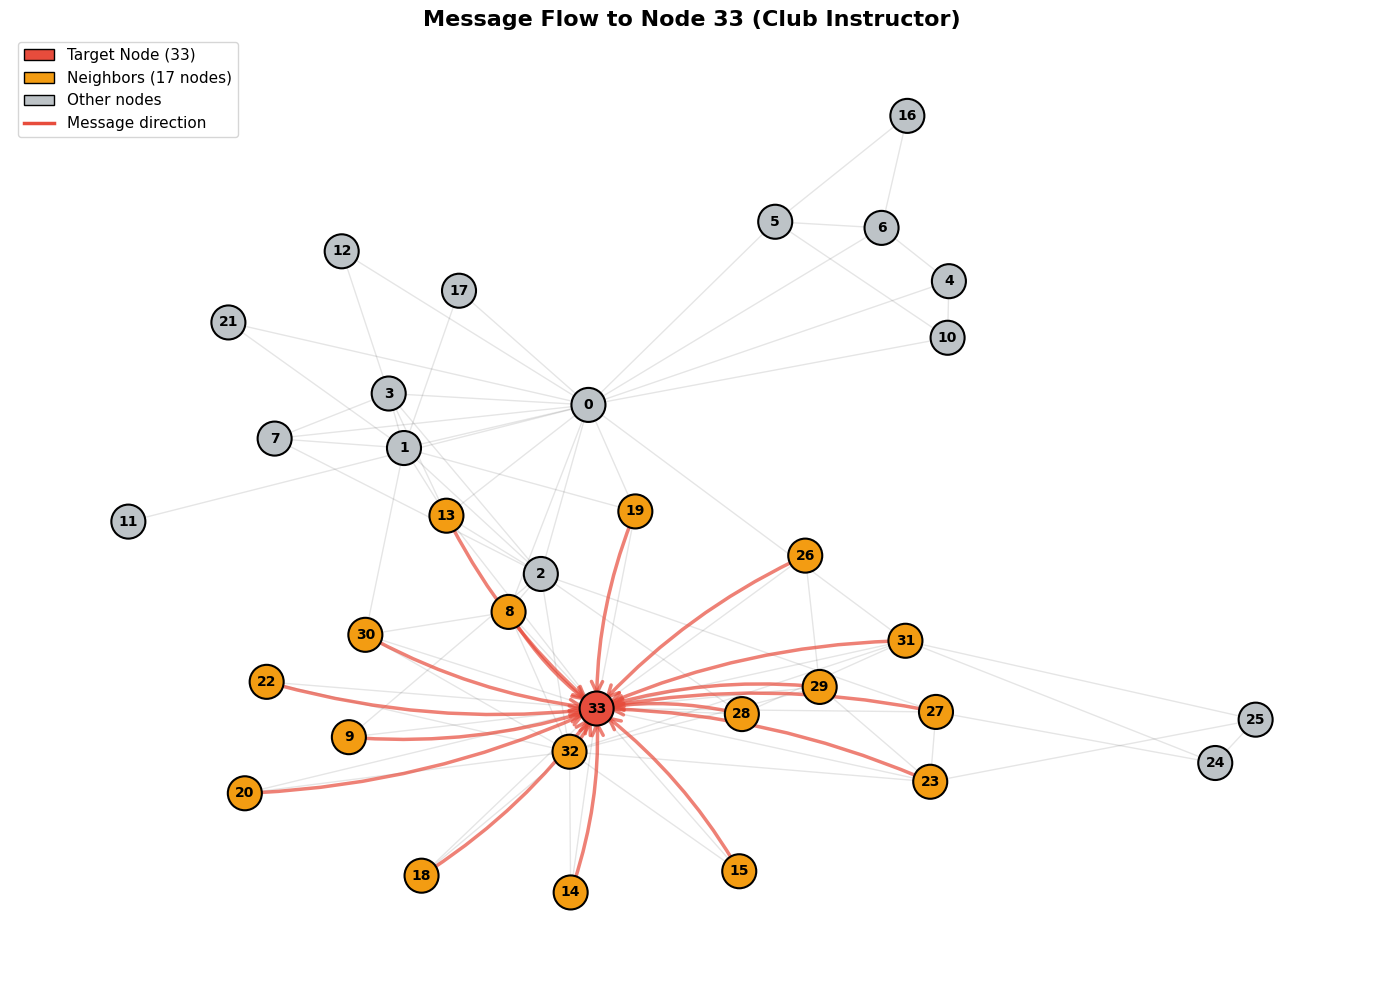

In [8]:
def visualize_message_flow(G, pos, target_node, edge_index, labels, title=None):
    """Visualize messages flowing toward a target node."""
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    # Find neighbors
    neighbors_set = set(G.neighbors(target_node))

    # Color nodes
    node_colors = []
    for n in G.nodes():
        if n == target_node:
            node_colors.append('#E74C3C')   # Red for target
        elif n in neighbors_set:
            node_colors.append('#F39C12')   # Orange for neighbors
        else:
            node_colors.append('#BDC3C7')   # Gray for others

    # Draw all edges (faint)
    nx.draw_networkx_edges(G, pos, alpha=0.1, width=1, ax=ax)

    # Highlight message edges
    message_edges = [(n, target_node) for n in neighbors_set]
    nx.draw_networkx_edges(G, pos, edgelist=message_edges,
                          edge_color='#E74C3C', width=2.5, alpha=0.7,
                          arrows=True, arrowstyle='->', arrowsize=20,
                          connectionstyle='arc3,rad=0.1', ax=ax)

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600,
                          edgecolors='black', linewidths=1.5, ax=ax)

    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)

    # Legend
    legend_elements = [
        mpatches.Patch(facecolor='#E74C3C', edgecolor='black',
                       label=f'Target Node ({target_node})'),
        mpatches.Patch(facecolor='#F39C12', edgecolor='black',
                       label=f'Neighbors ({len(neighbors_set)} nodes)'),
        mpatches.Patch(facecolor='#BDC3C7', edgecolor='black',
                       label='Other nodes'),
        Line2D([0], [0], color='#E74C3C', linewidth=2.5,
               label='Message direction'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11)

    if title:
        ax.set_title(title, fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Visualize messages flowing to Node 0
visualize_message_flow(G, pos, target_node=0, edge_index=data.edge_index,
                      labels=labels,
                      title='Message Flow to Node 0 (Club Administrator)')

# Also visualize for Node 33 (instructor)
visualize_message_flow(G, pos, target_node=33, edge_index=data.edge_index,
                      labels=labels,
                      title='Message Flow to Node 33 (Club Instructor)')

### 5.2 Receptive Field Growth Over Layers

A key concept in GNNs is the **receptive field** - the set of nodes that can influence a target node's representation.

- After **1 layer**: a node "sees" its direct neighbors (1-hop).
- After **2 layers**: a node "sees" neighbors of neighbors (2-hop).
- After **k layers**: a node "sees" its k-hop neighborhood.

Let's visualize how the receptive field of **Node 0** grows.

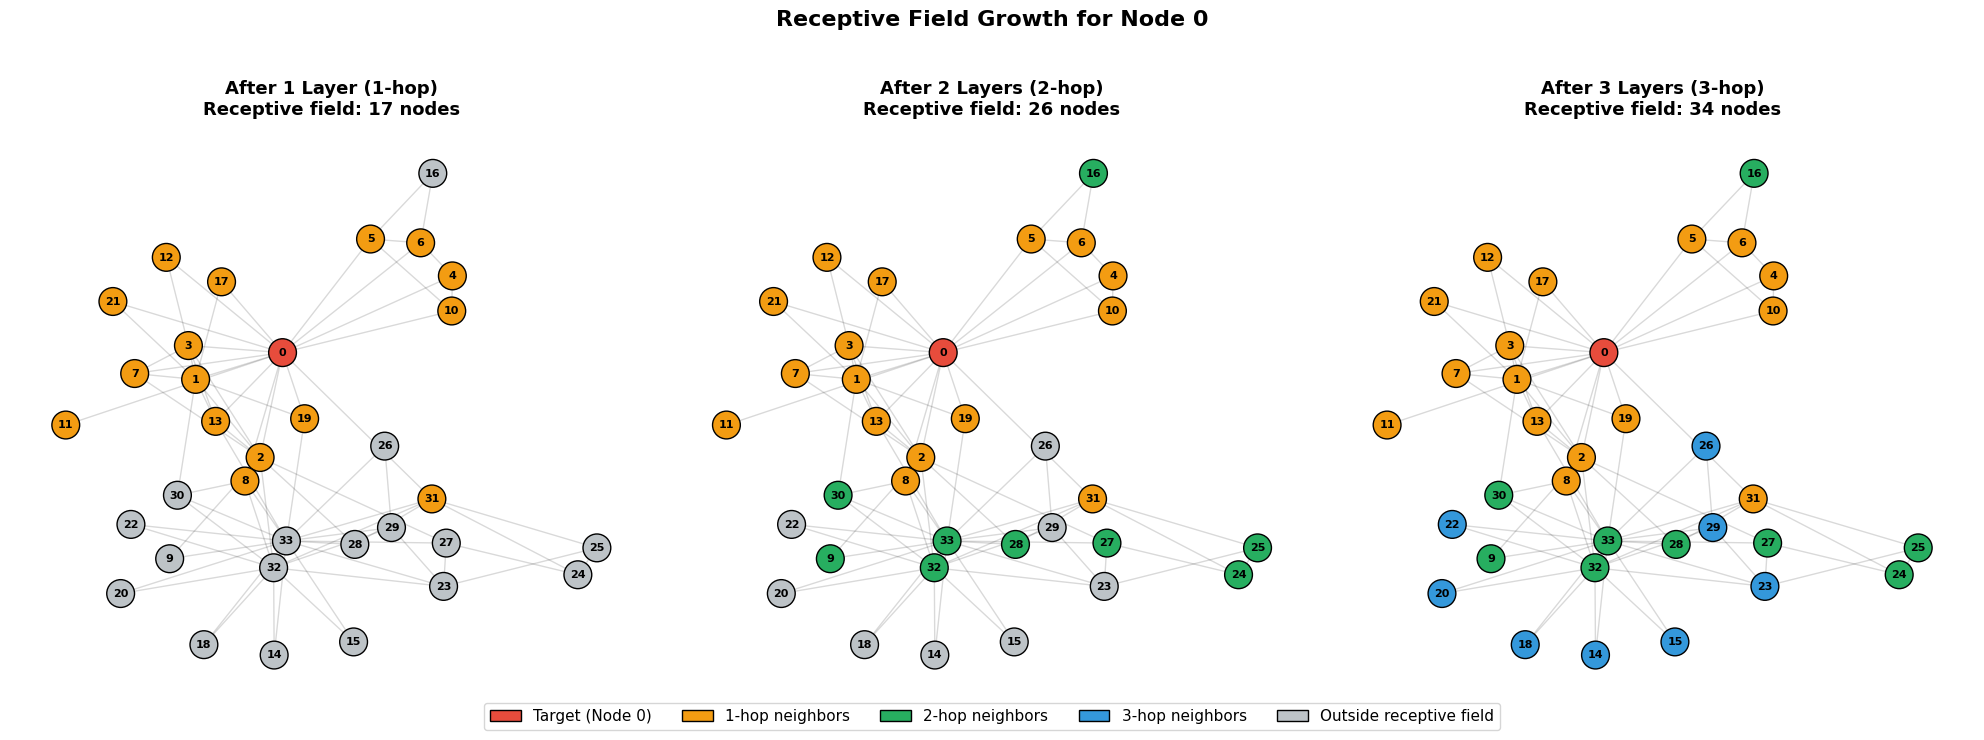

In [9]:
def get_k_hop_neighbors(G, target_node, k):
    """Get the set of nodes within k hops of the target node."""
    neighbors_by_hop = {0: {target_node}}
    all_neighbors = {target_node}

    for hop in range(1, k + 1):
        new_neighbors = set()
        for node in neighbors_by_hop[hop - 1]:
            for neighbor in G.neighbors(node):
                if neighbor not in all_neighbors:
                    new_neighbors.add(neighbor)
        neighbors_by_hop[hop] = new_neighbors
        all_neighbors |= new_neighbors

    return neighbors_by_hop, all_neighbors


target_node = 0
max_hops = 3

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

hop_colors = {
    0: '#E74C3C',   # Red for target
    1: '#F39C12',   # Orange for 1-hop
    2: '#27AE60',   # Green for 2-hop
    3: '#3498DB',   # Blue for 3-hop
}

for k in range(1, max_hops + 1):
    ax = axes[k - 1]
    neighbors_by_hop, all_neighbors = get_k_hop_neighbors(G, target_node, k)

    # Color nodes by hop distance
    node_colors = []
    for n in G.nodes():
        colored = False
        for hop in range(k + 1):
            if n in neighbors_by_hop.get(hop, set()):
                node_colors.append(hop_colors[hop])
                colored = True
                break
        if not colored:
            node_colors.append('#BDC3C7')

    # Draw
    nx.draw_networkx_edges(G, pos, alpha=0.15, width=1, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400,
                          edgecolors='black', linewidths=1, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

    ax.set_title(f'After {k} Layer{"s" if k > 1 else ""} ({k}-hop)\n'
                 f'Receptive field: {len(all_neighbors)} nodes',
                 fontsize=13, fontweight='bold')
    ax.axis('off')

# Add overall legend
legend_elements = [
    mpatches.Patch(facecolor=hop_colors[0], edgecolor='black', label=f'Target (Node {target_node})'),
    mpatches.Patch(facecolor=hop_colors[1], edgecolor='black', label='1-hop neighbors'),
    mpatches.Patch(facecolor=hop_colors[2], edgecolor='black', label='2-hop neighbors'),
    mpatches.Patch(facecolor=hop_colors[3], edgecolor='black', label='3-hop neighbors'),
    mpatches.Patch(facecolor='#BDC3C7', edgecolor='black', label='Outside receptive field'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=11,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(f'Receptive Field Growth for Node {target_node}',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 6. Manual Message Passing - Full Round

Now let's perform a complete round of message passing for **all nodes simultaneously** and see how the node representations change.

In [ ]:
def manual_message_passing(X, A_hat, W=None, activation=True):
    """
    Perform one round of GCN-style message passing.

    Steps:
      1. MESSAGE + AGGREGATE: H = A_hat @ X  (each node aggregates neighbor features)
      2. UPDATE: H = H @ W  (linear transformation)
      3. ACTIVATE: H = ReLU(H)  (non-linearity)

    Args:
        X: Node feature matrix [N, F_in]
        A_hat: Normalized adjacency matrix [N, N]
        W: Weight matrix [F_in, F_out] (optional)
        activation: Whether to apply ReLU

    Returns:
        Updated node features [N, F_out]
    """
    # Step 1: Aggregate (multiply by normalized adjacency)
    H = A_hat @ X
    print(f'  After AGGREGATE: shape = {H.shape}')

    # Step 2: Transform (multiply by weights)
    if W is not None:
        H = H @ W
        print(f'  After TRANSFORM: shape = {H.shape}')

    # Step 3: Activate (ReLU)
    if activation:
        H = F.relu(H)
        print(f'  After ACTIVATE:  shape = {H.shape}')

    return H


# Initialize features
X0 = torch.eye(num_nodes)  # [34, 34]

# Create a weight matrix (random initialization)
torch.manual_seed(42)
F_in, F_out = num_nodes, 16  # Reduce dimension from 34 to 16
W1 = torch.randn(F_in, F_out) * 0.1  # Small random init

print('Round 1 of Message Passing:')
print('=' * 50)
X1 = manual_message_passing(X0, A_hat, W1, activation=True)

print(f'\nInput features shape:  {X0.shape}')
print(f'Output features shape: {X1.shape}')
print(f'\nNode 0 - new embedding (first 8 dims):')
print(f'  {X1[0, :8].detach().numpy().round(4)}')
print(f'\nNode 33 - new embedding (first 8 dims):')
print(f'  {X1[33, :8].detach().numpy().round(4)}')

Round 1 of Message Passing:
  After AGGREGATE: shape = torch.Size([34, 34])
  After TRANSFORM: shape = torch.Size([34, 16])
  After ACTIVATE:  shape = torch.Size([34, 16])

Input features shape:  torch.Size([34, 34])
Output features shape: torch.Size([34, 16])

Node 0 — new embedding (first 8 dims):
  [0.0023 0.     0.     0.     0.     0.     0.     0.    ]

Node 33 — new embedding (first 8 dims):
  [0.0213 0.0067 0.0157 0.     0.     0.     0.     0.0291]


### 6.1 Multiple Rounds of Message Passing

Let's run multiple rounds and observe how the representations evolve.

In [11]:
# Run 3 rounds of message passing
torch.manual_seed(42)

# Initialize
X_current = torch.eye(num_nodes)
history = [X_current.detach().clone()]  # Store representations at each layer

# Weight matrices for 3 layers: 34 -> 16 -> 8 -> 4
dims = [34, 16, 8, 4]
weights = [torch.randn(dims[i], dims[i+1]) * 0.1 for i in range(3)]

for layer in range(3):
    print(f'\n--- Layer {layer + 1} ---')
    X_current = manual_message_passing(X_current, A_hat, weights[layer],
                                       activation=(layer < 2))  # No activation on last layer
    history.append(X_current.detach().clone())

print(f'\n\nRepresentation dimensions at each layer:')
for i, h in enumerate(history):
    print(f'  Layer {i}: {h.shape}')


--- Layer 1 ---
  After AGGREGATE: shape = torch.Size([34, 34])
  After TRANSFORM: shape = torch.Size([34, 16])
  After ACTIVATE:  shape = torch.Size([34, 16])

--- Layer 2 ---
  After AGGREGATE: shape = torch.Size([34, 16])
  After TRANSFORM: shape = torch.Size([34, 8])
  After ACTIVATE:  shape = torch.Size([34, 8])

--- Layer 3 ---
  After AGGREGATE: shape = torch.Size([34, 8])
  After TRANSFORM: shape = torch.Size([34, 4])


Representation dimensions at each layer:
  Layer 0: torch.Size([34, 34])
  Layer 1: torch.Size([34, 16])
  Layer 2: torch.Size([34, 8])
  Layer 3: torch.Size([34, 4])


---

## 7. Visualizing How Node Representations Change Over Time

Let's visualize how the node embeddings evolve after each message passing layer. We'll use:
1. **Heatmaps** to see the raw embedding values.
2. **Cosine similarity** to see which nodes become more or less similar.
3. **2D projections** (using PCA) to see the spatial arrangement of embeddings.

### 7.1 Embedding Heatmaps Across Layers

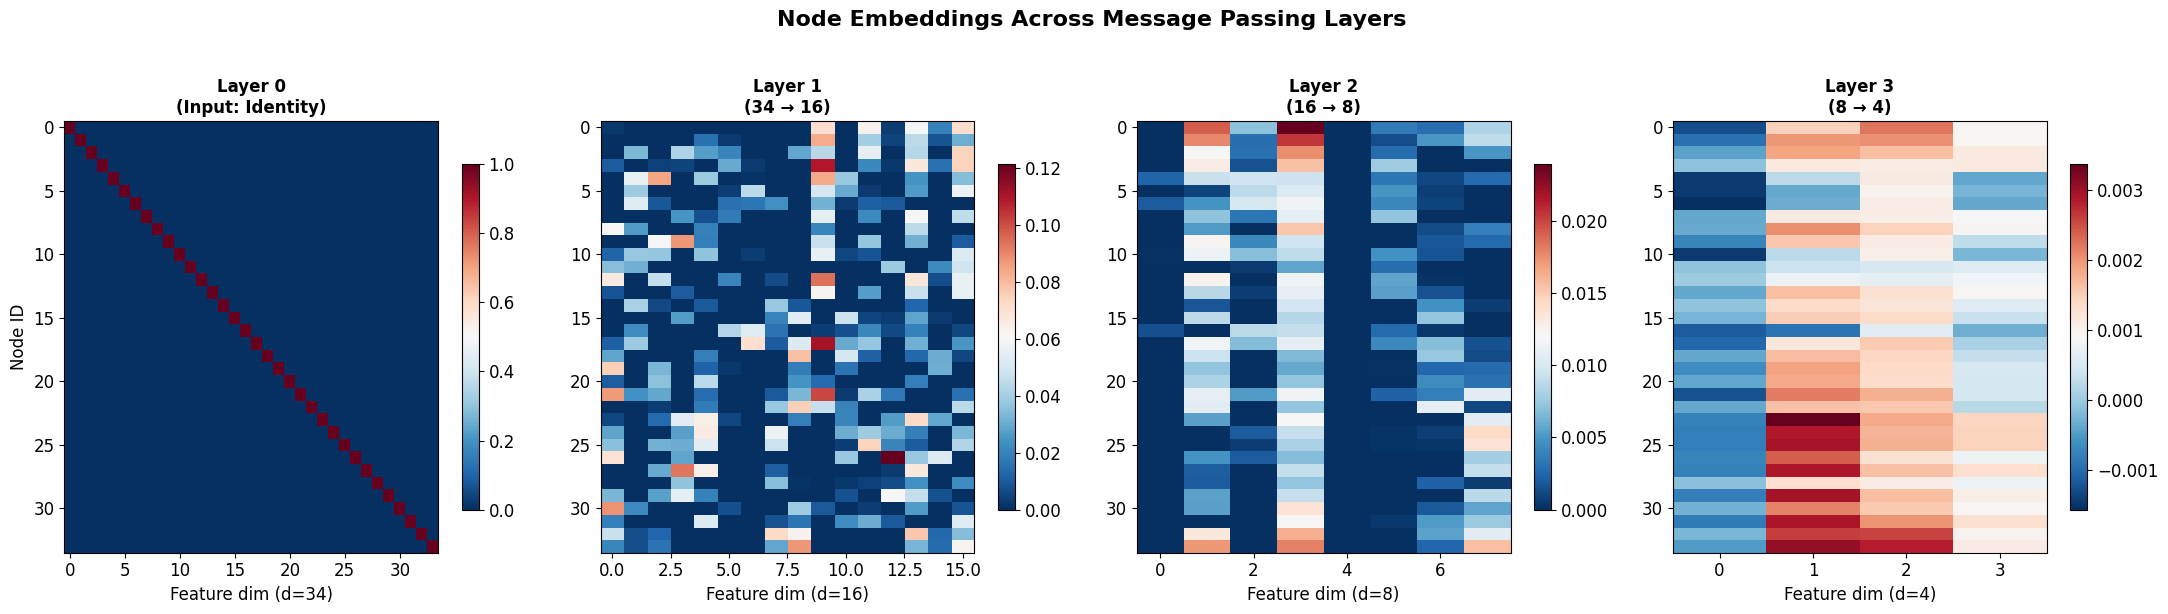

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

layer_names = ['Layer 0\n(Input: Identity)', 'Layer 1\n(34 → 16)',
               'Layer 2\n(16 → 8)', 'Layer 3\n(8 → 4)']

for i, (h, name) in enumerate(zip(history, layer_names)):
    ax = axes[i]
    h_np = h.numpy()

    im = ax.imshow(h_np, cmap='RdBu_r', aspect='auto', interpolation='none')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Node ID' if i == 0 else '')
    ax.set_xlabel(f'Feature dim (d={h.shape[1]})')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Node Embeddings Across Message Passing Layers',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.2 Node Similarity Before and After Message Passing

One key effect of message passing is that **neighboring nodes become more similar**. Let's verify this by computing cosine similarity between all node pairs.

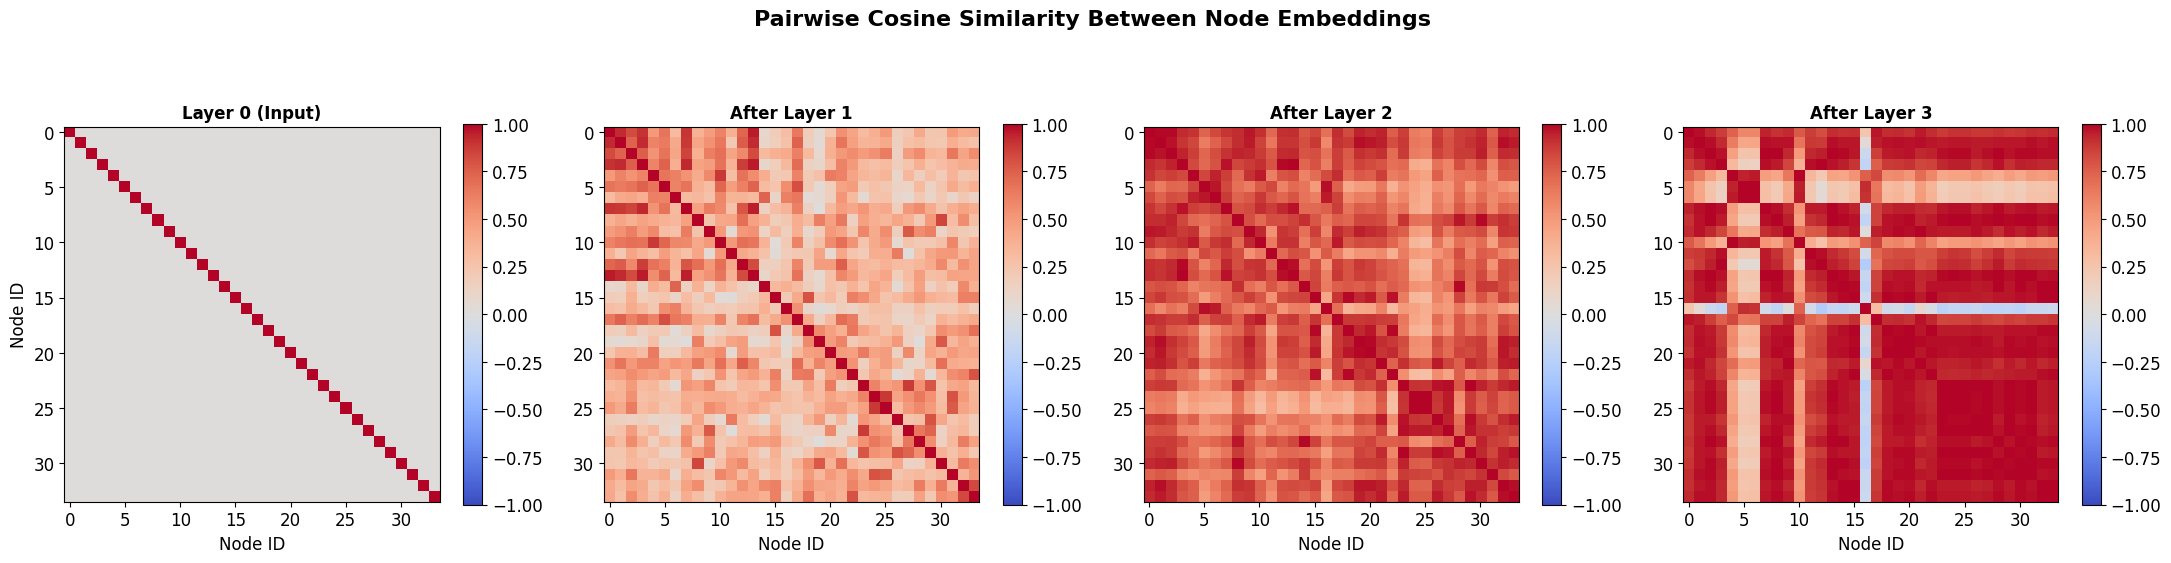

In [13]:
def cosine_similarity_matrix(H):
    """Compute pairwise cosine similarity between all node embeddings."""
    H_norm = F.normalize(H, p=2, dim=1)
    return (H_norm @ H_norm.T).numpy()


fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

layer_names = ['Layer 0 (Input)', 'After Layer 1', 'After Layer 2', 'After Layer 3']

for i, (h, name) in enumerate(zip(history, layer_names)):
    ax = axes[i]
    sim = cosine_similarity_matrix(h)

    im = ax.imshow(sim, cmap='coolwarm', vmin=-1, vmax=1,
                   interpolation='none')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Node ID')
    ax.set_ylabel('Node ID' if i == 0 else '')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Pairwise Cosine Similarity Between Node Embeddings',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation**: In Layer 0 (identity features), each node is orthogonal to all others (cosine similarity = 0 except with itself). After message passing, nodes in the same neighborhood develop **similar representations**, visible as block patterns in the similarity matrix.

### 7.3 2D Projections of Node Embeddings (PCA)

Let's project the node embeddings to 2D using PCA and color them by their ground-truth community.

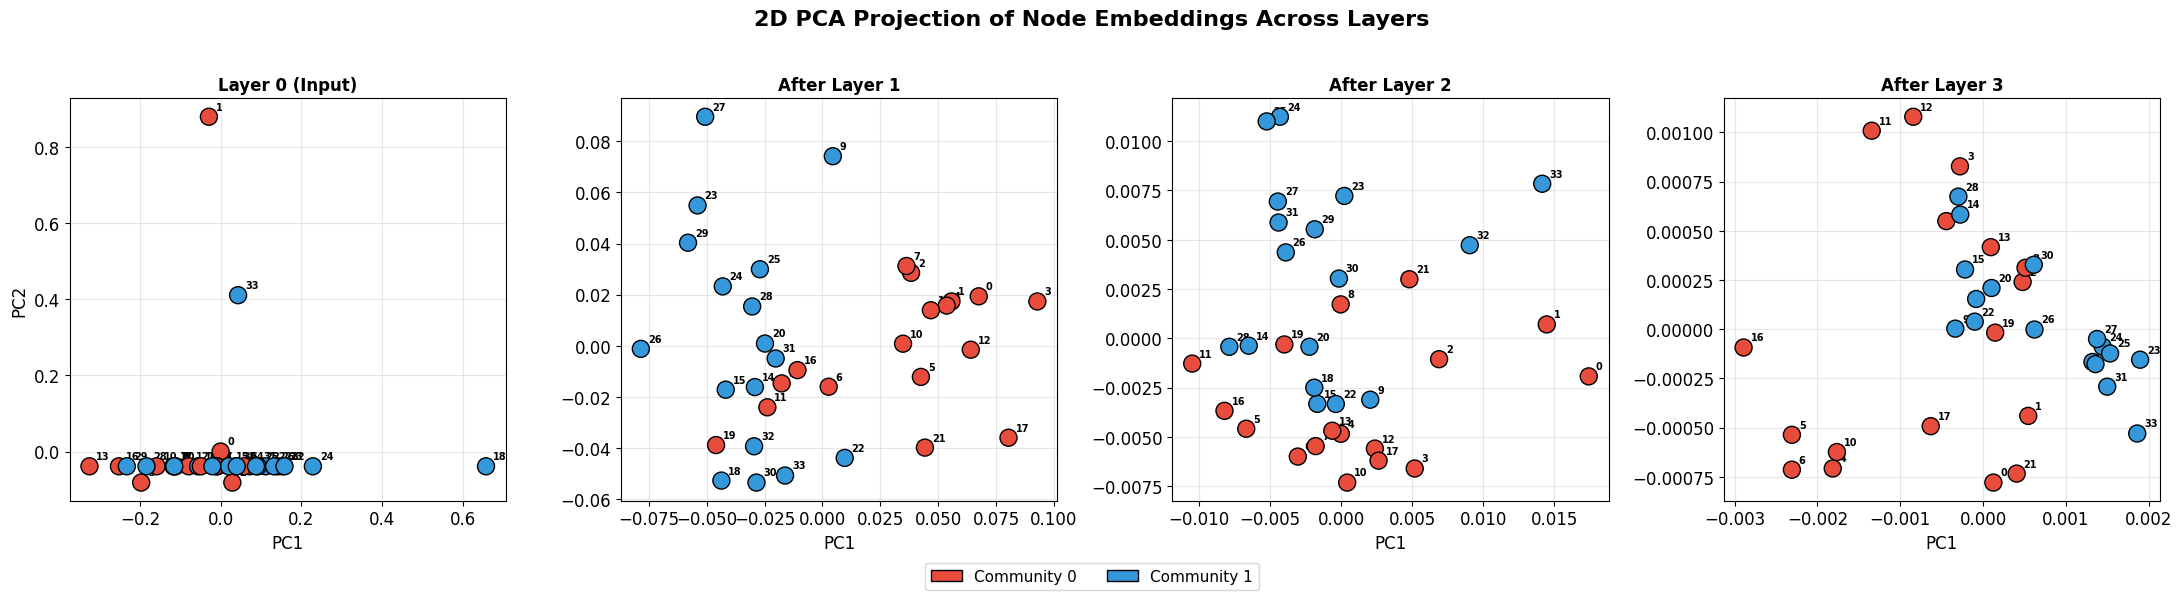

In [14]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

layer_names = ['Layer 0 (Input)', 'After Layer 1', 'After Layer 2', 'After Layer 3']

# Color by ground-truth community
community_colors = ['#E74C3C' if labels[i] == 0 else '#3498DB'
                     if labels[i] == 1 else '#27AE60'
                     if labels[i] == 2 else '#F39C12'
                     for i in range(num_nodes)]

for i, (h, name) in enumerate(zip(history, layer_names)):
    ax = axes[i]
    h_np = h.numpy()

    # PCA to 2D
    if h_np.shape[1] >= 2:
        pca = PCA(n_components=2)
        h_2d = pca.fit_transform(h_np)
    else:
        h_2d = h_np

    ax.scatter(h_2d[:, 0], h_2d[:, 1], c=community_colors,
               s=150, edgecolors='black', linewidths=1, zorder=5)

    # Add node labels
    for j in range(num_nodes):
        ax.annotate(str(j), (h_2d[j, 0], h_2d[j, 1]),
                    textcoords='offset points', xytext=(5, 5),
                    fontsize=7, fontweight='bold')

    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2' if i == 0 else '')
    ax.grid(True, alpha=0.3)

# Legend
unique_labels = np.unique(labels)
color_list = ['#E74C3C', '#3498DB', '#27AE60', '#F39C12']
legend_elements = [mpatches.Patch(facecolor=color_list[lbl], edgecolor='black',
                                  label=f'Community {lbl}')
                   for lbl in unique_labels]
fig.legend(handles=legend_elements, loc='lower center', ncol=len(unique_labels),
           fontsize=11, bbox_to_anchor=(0.5, -0.05))

fig.suptitle('2D PCA Projection of Node Embeddings Across Layers',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 8. Building a Custom GCN Layer with PyG's MessagePassing

Now let's implement a proper GCN layer using PyTorch Geometric's `MessagePassing` base class. This gives us a structured way to define the **message**, **aggregate**, and **update** functions.

In [ ]:
class CustomGCNConv(MessagePassing):
    """
    A custom Graph Convolutional Network layer built using
    PyTorch Geometric's MessagePassing framework.

    This implements the GCN update rule:
      h_v^(k) = sigma( W^(k) * SUM_{u in N(v) U {v}}
                       (1/sqrt(deg(v)) * 1/sqrt(deg(u))) * h_u^(k-1) )

    The MessagePassing class requires us to define:
      - __init__: Set aggregation type ('add', 'mean', 'max')
      - forward: Pre-process, compute normalization, call propagate()
      - message: Define what each neighbor sends (message function)
      - update: Post-process aggregated messages (update function)
    """

    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')  # Sum aggregation

        # Learnable weight matrix W: [in_channels, out_channels]
        self.lin = nn.Linear(in_channels, out_channels, bias=False)

        # Learnable bias
        self.bias = nn.Parameter(torch.zeros(out_channels))

        self.reset_parameters()

    def reset_parameters(self):
        self.lin.reset_parameters()
        self.bias.data.zero_()

    def forward(self, x, edge_index):
        """
        Forward pass:
          1. Add self-loops to the edge index
          2. Linearly transform node features
          3. Compute normalization coefficients
          4. Propagate messages (this calls message() + aggregate())
          5. Apply bias
        """
        # Step 1: Add self-loops
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        # Step 2: Linear transformation
        x = self.lin(x)

        # Step 3: Compute normalization coefficients
        row, col = edge_index
        deg = degree(col, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]

        # Step 4: Propagate (calls message() and aggregate())
        out = self.propagate(edge_index, x=x, norm=norm)

        # Step 5: Add bias
        out = out + self.bias

        return out

    def message(self, x_j, norm):
        """
        The MESSAGE function.

        For each edge (j -> i), compute the message that node j sends to node i.
        x_j contains the features of the source node j.
        norm contains the normalization coefficient for this edge.

        Message = norm * x_j
        """
        return norm.view(-1, 1) * x_j


print('Custom GCN layer defined successfully!')
print('\nThe three key methods:')
print('  1. forward()  - orchestrates the entire message passing process')
print('  2. message()  - defines what each neighbor sends (norm * x_j)')
print('  3. aggregate - handled by MessagePassing with aggr="add" (sum)')

Custom GCN layer defined successfully!

The three key methods:
  1. forward()  — orchestrates the entire message passing process
  2. message()  — defines what each neighbor sends (norm * x_j)
  3. aggregate — handled by MessagePassing with aggr="add" (sum)


---

## 9. Full GNN Model for Node Classification

Let's build a complete GNN model using our custom layer and train it on the Karate Club node classification task.

### 9.1 Model Definition

In [ ]:
class KarateClubGNN(nn.Module):
    """
    A 3-layer GNN for node classification on the Karate Club.

    Architecture:
      Input (34 features) → GCN Layer 1 (16) → ReLU → Dropout
                          → GCN Layer 2 (8)  → ReLU → Dropout
                          → GCN Layer 3 (num_classes) → Log-Softmax
    """

    def __init__(self, num_features, num_classes, hidden_dim=16):
        super().__init__()
        self.conv1 = CustomGCNConv(num_features, hidden_dim)
        self.conv2 = CustomGCNConv(hidden_dim, hidden_dim // 2)
        self.conv3 = CustomGCNConv(hidden_dim // 2, num_classes)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x, edge_index):
        # Layer 1: Message Passing + ReLU
        h1 = self.conv1(x, edge_index)
        h1 = F.relu(h1)
        h1 = self.dropout(h1)

        # Layer 2: Message Passing + ReLU
        h2 = self.conv2(h1, edge_index)
        h2 = F.relu(h2)
        h2 = self.dropout(h2)

        # Layer 3: Message Passing (no activation - raw logits)
        h3 = self.conv3(h2, edge_index)

        return h1, h2, h3  # Return intermediate representations too

    def predict(self, x, edge_index):
        _, _, logits = self.forward(x, edge_index)
        return F.log_softmax(logits, dim=1)


# Instantiate
model = KarateClubGNN(
    num_features=data.num_node_features,
    num_classes=num_classes
)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters())}')

KarateClubGNN(
  (conv1): CustomGCNConv()
  (conv2): CustomGCNConv()
  (conv3): CustomGCNConv()
  (dropout): Dropout(p=0.5, inplace=False)
)

Total parameters: 714


### 9.2 Training Loop

In [17]:
# Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

# Store training history
train_losses = []
train_accs = []
total_accs = []

# Store embeddings at different epochs for visualization
embedding_snapshots = {}

num_epochs = 200

print('Training the GNN...')
print('=' * 60)

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    h1, h2, logits = model(data.x, data.edge_index)

    # Loss (only on training nodes)
    loss = criterion(logits[data.train_mask], data.y[data.train_mask])

    # Backward pass
    loss.backward()
    optimizer.step()

    # Compute accuracy
    model.eval()
    with torch.no_grad():
        h1_eval, h2_eval, logits_eval = model(data.x, data.edge_index)
        pred = logits_eval.argmax(dim=1)
        train_correct = (pred[data.train_mask] == data.y[data.train_mask]).sum()
        train_acc = int(train_correct) / int(data.train_mask.sum())
        total_correct = (pred == data.y).sum()
        total_acc = int(total_correct) / data.num_nodes

    train_losses.append(loss.item())
    train_accs.append(train_acc)
    total_accs.append(total_acc)

    # Save embedding snapshots
    if epoch in [0, 10, 50, 100, 199]:
        model.eval()
        with torch.no_grad():
            h1_snap, h2_snap, h3_snap = model(data.x, data.edge_index)
            embedding_snapshots[epoch] = {
                'layer1': h1_snap.clone(),
                'layer2': h2_snap.clone(),
                'layer3': h3_snap.clone(),
            }

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/{num_epochs} | '
              f'Loss: {loss.item():.4f} | '
              f'Train Acc: {train_acc:.4f} | '
              f'Total Acc: {total_acc:.4f}')

print('=' * 60)
print('Training complete!')

Training the GNN...
Epoch  20/200 | Loss: 0.3530 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch  40/200 | Loss: 0.0373 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch  60/200 | Loss: 0.0013 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch  80/200 | Loss: 0.0010 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch 100/200 | Loss: 0.0174 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch 120/200 | Loss: 0.0003 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch 140/200 | Loss: 0.0005 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch 160/200 | Loss: 0.0001 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch 180/200 | Loss: 0.0002 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch 200/200 | Loss: 0.0010 | Train Acc: 1.0000 | Total Acc: 0.9706
Training complete!


### 9.3 Training Curves

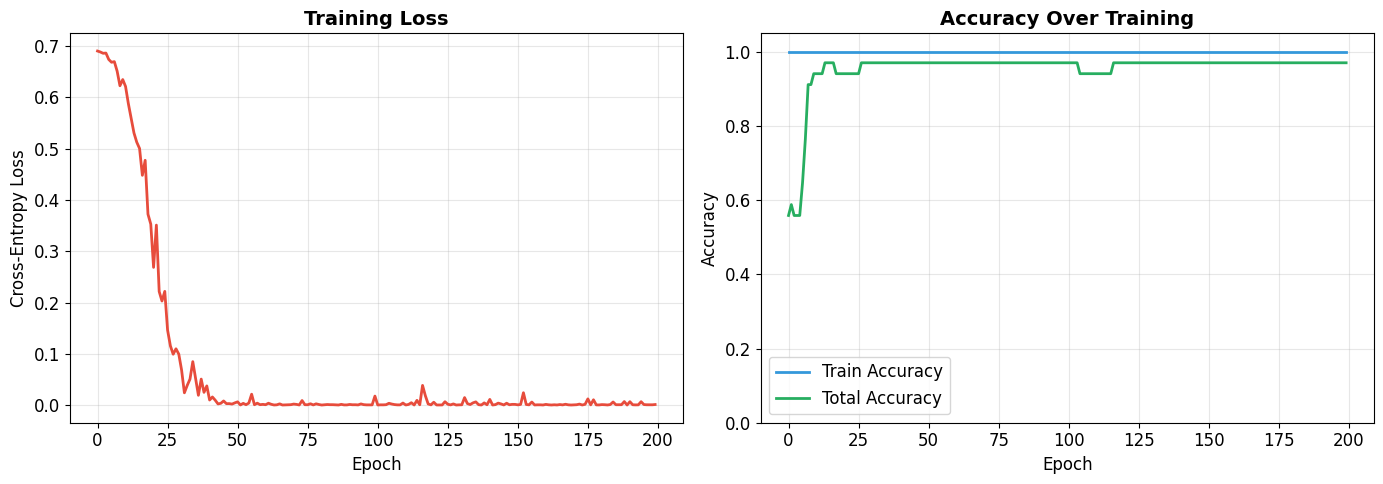

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_losses, color='#E74C3C', linewidth=2)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(train_accs, color='#3498DB', linewidth=2, label='Train Accuracy')
axes[1].plot(total_accs, color='#27AE60', linewidth=2, label='Total Accuracy')
axes[1].set_title('Accuracy Over Training', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

---

## 10. How Learned Representations Evolve During Training

Now let's visualize how the node embeddings change as the model trains. We'll look at snapshots from epochs 0 (random), 10, 50, 100, and 200.

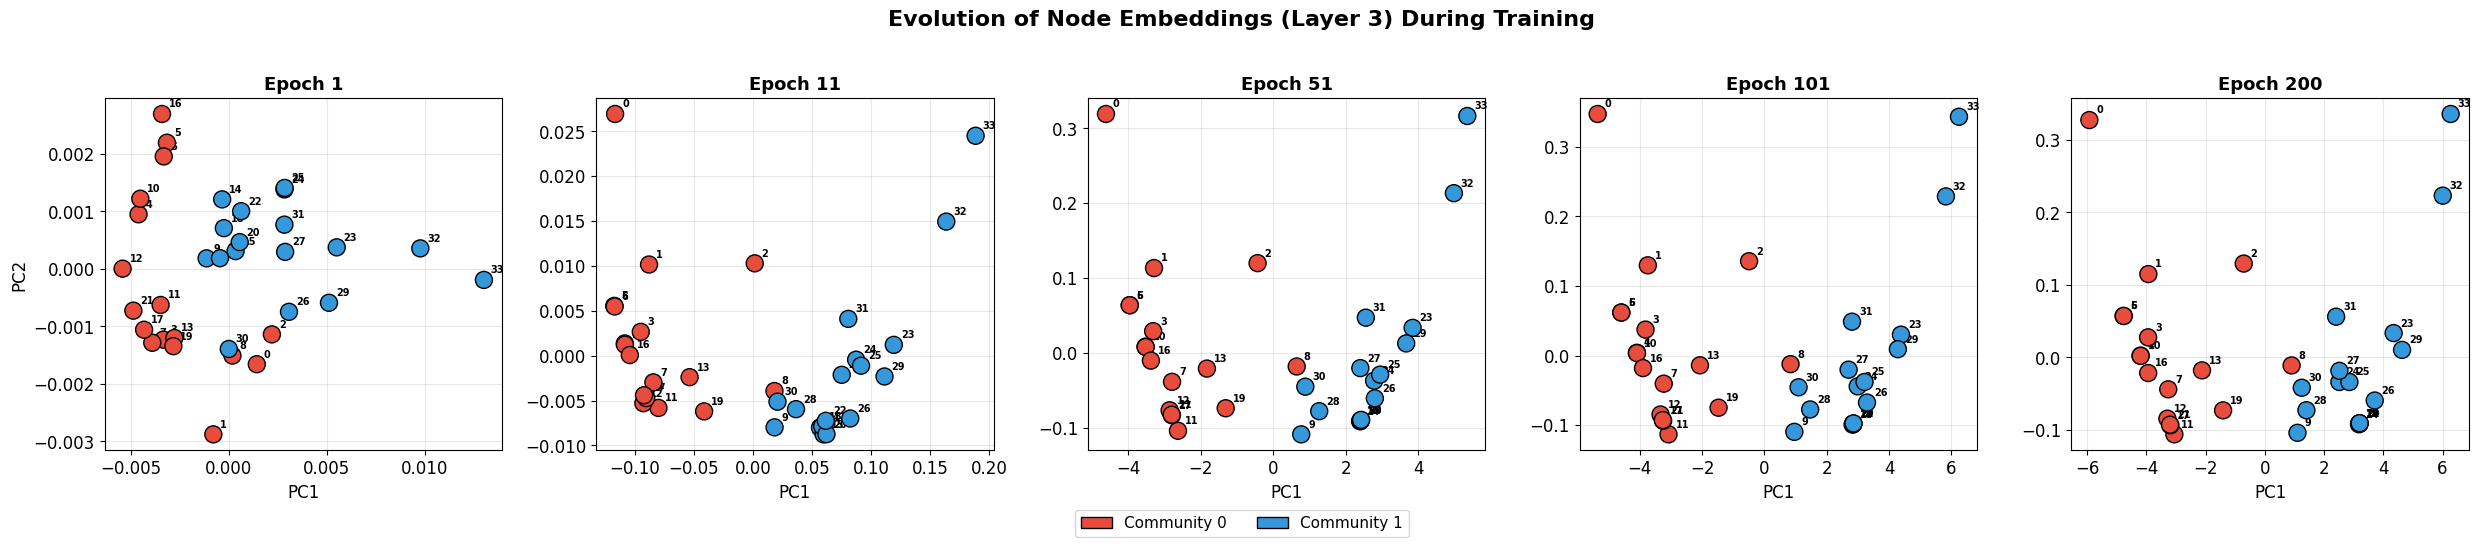

In [19]:
from sklearn.decomposition import PCA

# We'll visualize the last layer's (Layer 3) embeddings across training epochs
snapshot_epochs = sorted(embedding_snapshots.keys())
num_snapshots = len(snapshot_epochs)

fig, axes = plt.subplots(1, num_snapshots, figsize=(5 * num_snapshots, 5))

# Color by ground-truth community
community_colors = ['#E74C3C' if labels[i] == 0 else '#3498DB'
                     if labels[i] == 1 else '#27AE60'
                     if labels[i] == 2 else '#F39C12'
                     for i in range(num_nodes)]

for idx, epoch in enumerate(snapshot_epochs):
    ax = axes[idx]
    h = embedding_snapshots[epoch]['layer3'].numpy()

    # PCA to 2D
    if h.shape[1] >= 2:
        pca = PCA(n_components=2)
        h_2d = pca.fit_transform(h)
    else:
        h_2d = np.column_stack([h, np.zeros(len(h))])

    ax.scatter(h_2d[:, 0], h_2d[:, 1], c=community_colors,
               s=150, edgecolors='black', linewidths=1, zorder=5)

    # Add node labels for key nodes
    for j in range(num_nodes):
        ax.annotate(str(j), (h_2d[j, 0], h_2d[j, 1]),
                    textcoords='offset points', xytext=(5, 5),
                    fontsize=7, fontweight='bold')

    ax.set_title(f'Epoch {epoch + 1}', fontsize=13, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2' if idx == 0 else '')
    ax.grid(True, alpha=0.3)

# Legend
unique_labels = np.unique(labels)
color_list = ['#E74C3C', '#3498DB', '#27AE60', '#F39C12']
legend_elements = [mpatches.Patch(facecolor=color_list[lbl], edgecolor='black',
                                  label=f'Community {lbl}')
                   for lbl in unique_labels]
fig.legend(handles=legend_elements, loc='lower center', ncol=len(unique_labels),
           fontsize=11, bbox_to_anchor=(0.5, -0.05))

fig.suptitle('Evolution of Node Embeddings (Layer 3) During Training',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation**: As training progresses, nodes from the **same community cluster together** and nodes from **different communities separate**. This is exactly what we want for node classification - the message passing mechanism combined with gradient descent learns to produce discriminative embeddings.

---

## 11. Comparison: Custom Layer vs. PyG's Built-in GCNConv

Let's verify that our custom implementation produces similar results to PyTorch Geometric's built-in `GCNConv`.

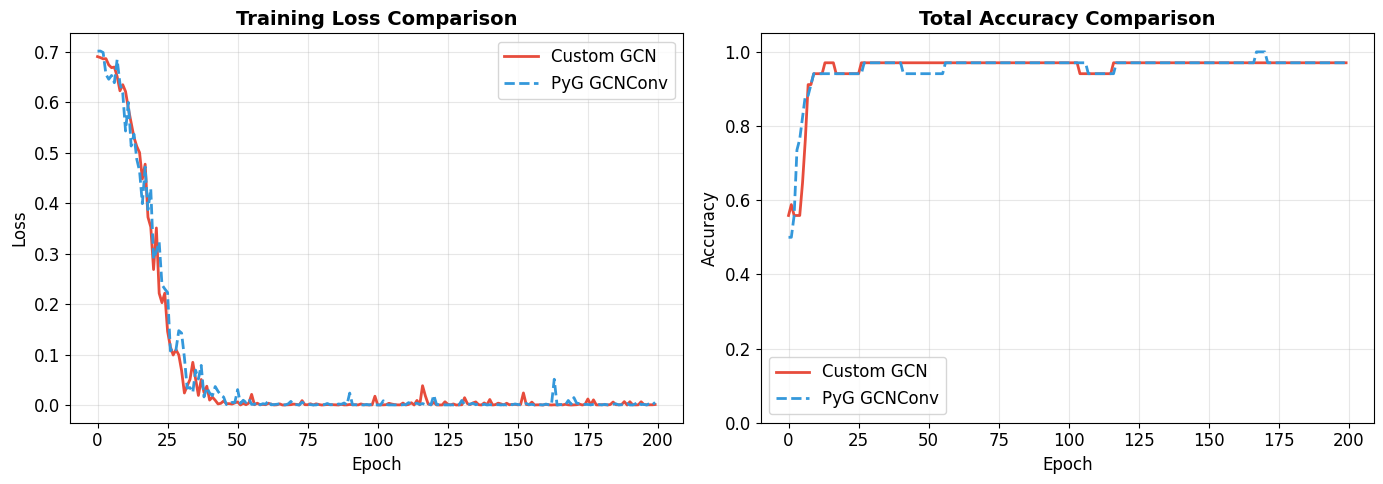


Final Total Accuracy — Custom GCN: 0.9706
Final Total Accuracy — PyG GCNConv: 0.9706


In [ ]:
class PyGGCN(nn.Module):
    """GNN using PyG's built-in GCNConv for comparison."""

    def __init__(self, num_features, num_classes, hidden_dim=16):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim // 2)
        self.conv3 = GCNConv(hidden_dim // 2, num_classes)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = self.dropout(h)

        h = self.conv2(h, edge_index)
        h = F.relu(h)
        h = self.dropout(h)

        h = self.conv3(h, edge_index)
        return h


# Train PyG model
torch.manual_seed(42)
pyg_model = PyGGCN(data.num_node_features, num_classes)
pyg_optimizer = torch.optim.Adam(pyg_model.parameters(), lr=0.01, weight_decay=5e-4)

pyg_losses = []
pyg_total_accs = []

for epoch in range(num_epochs):
    pyg_model.train()
    pyg_optimizer.zero_grad()
    logits = pyg_model(data.x, data.edge_index)
    loss = criterion(logits[data.train_mask], data.y[data.train_mask])
    loss.backward()
    pyg_optimizer.step()

    pyg_model.eval()
    with torch.no_grad():
        logits_eval = pyg_model(data.x, data.edge_index)
        pred = logits_eval.argmax(dim=1)
        total_acc = (pred == data.y).sum().item() / data.num_nodes

    pyg_losses.append(loss.item())
    pyg_total_accs.append(total_acc)

# Compare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, color='#E74C3C', linewidth=2, label='Custom GCN')
axes[0].plot(pyg_losses, color='#3498DB', linewidth=2, linestyle='--', label='PyG GCNConv')
axes[0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(total_accs, color='#E74C3C', linewidth=2, label='Custom GCN')
axes[1].plot(pyg_total_accs, color='#3498DB', linewidth=2, linestyle='--', label='PyG GCNConv')
axes[1].set_title('Total Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print(f'\nFinal Total Accuracy - Custom GCN: {total_accs[-1]:.4f}')
print(f'Final Total Accuracy - PyG GCNConv: {pyg_total_accs[-1]:.4f}')

---

## 12. Final Results - Visualizing Predictions on the Graph

Let's overlay the model's predictions on the original graph to see how well the GNN classifies each node.

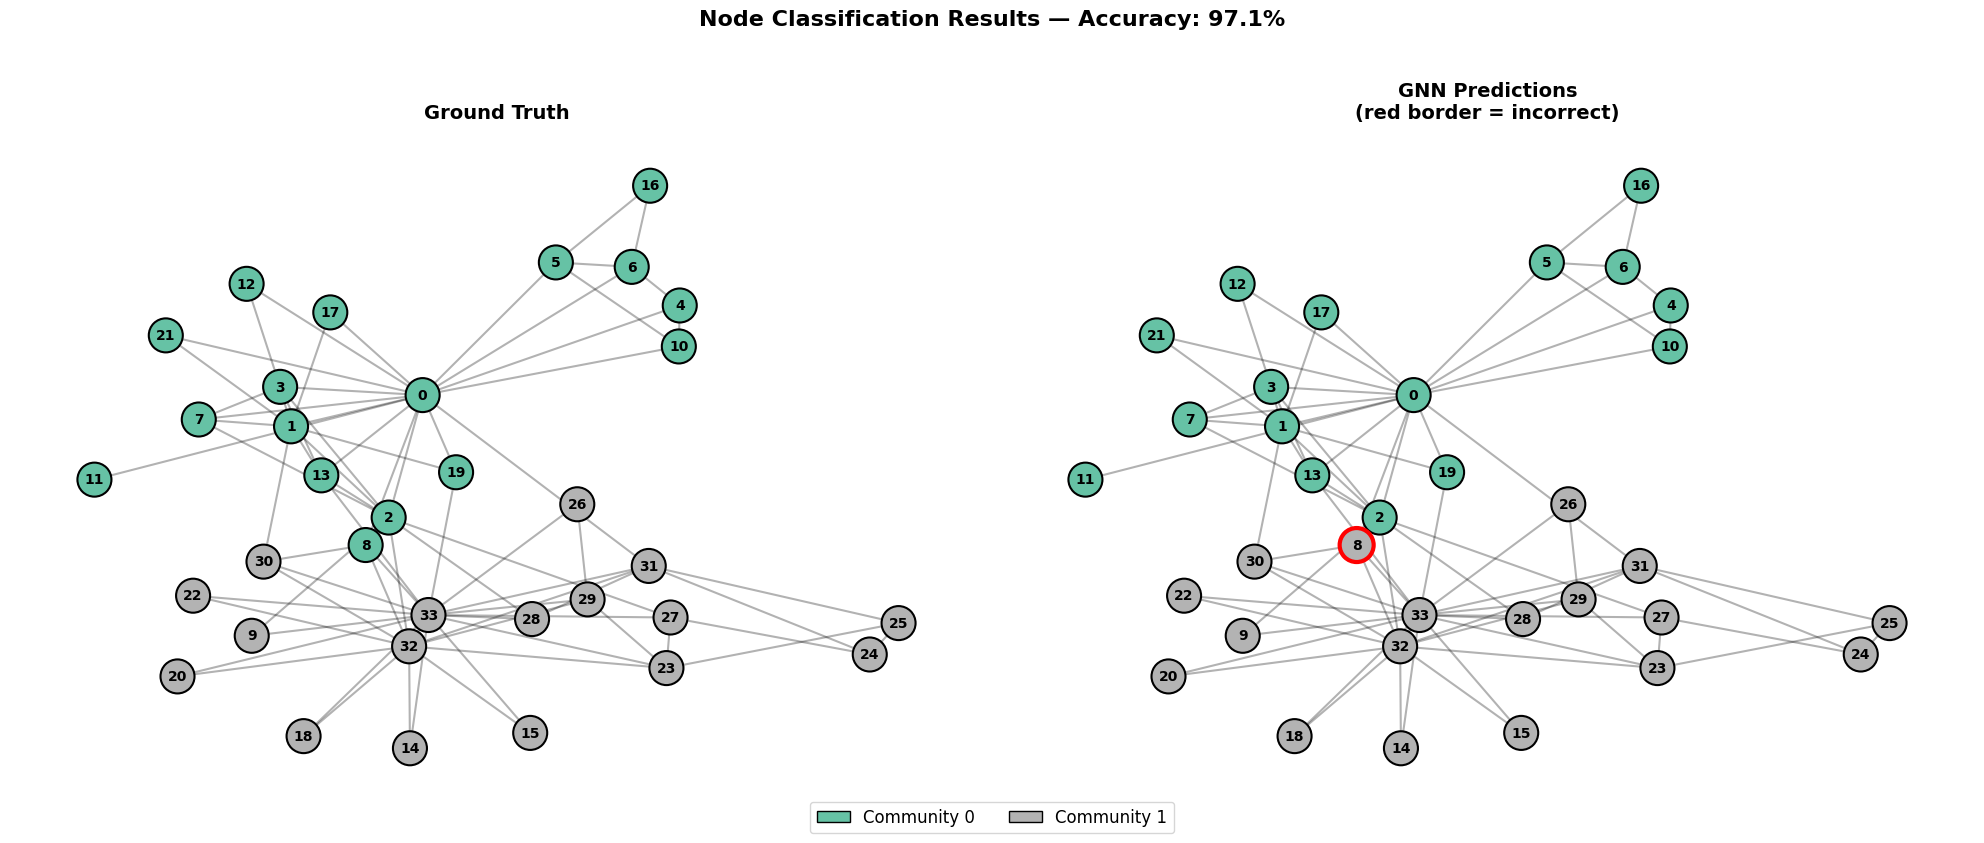


Classification Report:
  Correctly classified: 33/34
  Accuracy: 97.1%
  Misclassified nodes: [8]


In [ ]:
# Get final predictions from our custom model
model.eval()
with torch.no_grad():
    _, _, final_logits = model(data.x, data.edge_index)
    final_pred = final_logits.argmax(dim=1).numpy()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Ground truth
ax = axes[0]
gt_colors = [cmap(labels[i]) for i in range(num_nodes)]
nx.draw_networkx_edges(G, pos, alpha=0.3, width=1.5, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=gt_colors, node_size=600,
                       edgecolors='black', linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
ax.set_title('Ground Truth', fontsize=14, fontweight='bold')
ax.axis('off')

# Predictions
ax = axes[1]
pred_colors = [cmap(final_pred[i]) for i in range(num_nodes)]

# Mark incorrect predictions
incorrect = final_pred != labels
node_borders = ['red' if incorrect[i] else 'black' for i in range(num_nodes)]
node_border_widths = [3 if incorrect[i] else 1.5 for i in range(num_nodes)]

nx.draw_networkx_edges(G, pos, alpha=0.3, width=1.5, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=pred_colors, node_size=600,
                       edgecolors=node_borders, linewidths=node_border_widths, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
ax.set_title('GNN Predictions\n(red border = incorrect)', fontsize=14, fontweight='bold')
ax.axis('off')

# Overall legend
legend_elements = [mpatches.Patch(facecolor=cmap(i), edgecolor='black',
                                  label=f'Community {i}')
                   for i in range(num_classes)]
fig.legend(handles=legend_elements, loc='lower center', ncol=num_classes,
           fontsize=12, bbox_to_anchor=(0.5, -0.02))

accuracy = (final_pred == labels).mean()
fig.suptitle(f'Node Classification Results - Accuracy: {accuracy:.1%}',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Print summary
print(f'\nClassification Report:')
print(f'  Correctly classified: {(final_pred == labels).sum()}/{num_nodes}')
print(f'  Accuracy: {accuracy:.1%}')
if incorrect.any():
    print(f'  Misclassified nodes: {np.where(incorrect)[0].tolist()}')